In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.linalg import ishermitian, eigvals, eigvalsh
from scipy.sparse import kron, eye, diags, csc_matrix, hstack, vstack, random
from scipy.sparse.linalg import expm, expm_multiply, spsolve, norm
from scipy.optimize import curve_fit

from utils import *
from schrodingerization_utils import *

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import SparsePauliOp, operators
from qiskit import transpile
from qiskit import Aer
from ionq_circuit_utils import save_as_native_circuit, get_circuit_from_qiskit, get_native_circuit, get_native_gate_counts, \
    get_ionq_job_json, send_job, cancel_job, get_ionq_single_job_result

# from pytket import OpType, Circuit
# from pytket.circuit import StatePreparationBox
# from pytket.passes import DecomposeBoxes, RebaseCustom, RemoveRedundancies, CommuteThroughMultis, RepeatPass, SequencePass, FullPeepholeOptimise, auto_rebase_pass
# from pytket.extensions.qiskit import qiskit_to_tk, tk_to_qiskit
# from pytket.circuit.display import render_circuit_jupyter

import hashlib
import json

from os.path import join
from time import sleep

In [2]:
DATA_DIR = "experiment_data"
TASK_DIR = "schrodingerization"

CURR_DIR = DATA_DIR
check_and_make_dir(CURR_DIR)
CURR_DIR = join(CURR_DIR, TASK_DIR)
check_and_make_dir(CURR_DIR)

print(CURR_DIR)

use_real_machine = False
if use_real_machine:
    device = "qpu.aria-1"
else:
    device = "simulator"
print("Device:", device)

experiment_data/schrodingerization
Device: simulator


In [3]:
def sum_J_yx_minus_xy(n : int, J : np.ndarray) -> np.ndarray:

    assert n > 0
    assert J.shape == (n,n)

    dims = [2 ** i for i in range(n)]

    res = csc_matrix((2 ** n, 2 ** n))
    for i in range(n):
        for j in range(i):
            res += (J[i,j]) * (tensor([identity(dims[n-i-1], format='csr'), PAULI_Y, identity(dims[i-j-1], format='csr'), PAULI_X, identity(dims[j], format='csr')]) - \
                tensor([identity(dims[n-i-1], format='csr'), PAULI_X, identity(dims[i-j-1], format='csr'), PAULI_Y, identity(dims[j], format='csr')]))
            
    return res

# Schrodingerization for non-Hermitian spin systems

We want to simulate
$$
    x'(t) = A x(t)\\
    x(0) = x_0,
$$
where 
$$
    A=-i\left(J\sum_{j=1}^{n_x-1} Z_j Z_{j+1} + h\sum_{j=1}^{n_x} X_j \right) + \gamma\sum_{j=1}^{n_x} (Z_j - I)
$$

So, $A=H_1 + iH_2$ where
\begin{align}
    H_1 &= \gamma \sum_{j=1}^{n_x} (Z_j - I),\\
    H_2 &=-\left(J\sum_{j=1}^{n_x-1} Z_j Z_{j+1} + h\sum_{j=1}^{n_x} X_j \right).
\end{align}

Here, $\tilde{A}=H_1+iH_2$ and we are effectively doing $e^{-\tilde{A}t}$, so larger $H_1$ corresponds to larger damping.
After mapping to Hamiltonian simulation, $H_2$ is the Hermitian part, and $H_1$ corresponds to the anti-Hermitian part.
So for better robustness we expect we want to make $H_1$ smaller.

In [25]:
'''Modifiable parameters'''
n_p = 5                         # Number of qubits for p
n_x = 2                         # Number of qubits for x
R = 8                           # Right boundary endpoint
T = 4                          # Evolution time
N_t = 16                        # Number of time points
r = 5                           # Number of Trotter steps

J = 1
h = -1
gamma = 0.05  
num_shots = 4000                # Number of shots
trotter_method = "second_order"
qft_approx_degree = 0

N_p = 2 ** n_p
h_p = (2 * R) / (N_p - 1)
p = np.linspace(-R, R, N_p)
print("N_p:", N_p)
print(f"Total number of qubits: {n_p + n_x}")
t_vals = np.linspace(0, T, N_t)

H_1 = - gamma * sum_delta_n(n_x, delta=2 * np.ones(n_x))
H_2 = - (h * sum_x(n_x) + J * sum_J_zz(n_x, diags([np.ones(n_x-1)], [1]).toarray()))

A = H_1 + 1j * H_2

print("H1:", H_1.toarray())
print("H2:", H_2.toarray())
print(f"Norm of H1: {np.linalg.norm(H_1.toarray(), ord=2):0.3f}")
print(f"Norm of H2: {np.linalg.norm(H_2.toarray(), ord=2):0.3f}")

N_p: 32
Total number of qubits: 7
H1: [[ 0.   0.   0.   0. ]
 [ 0.  -0.1  0.   0. ]
 [ 0.   0.  -0.1  0. ]
 [ 0.   0.   0.  -0.2]]
H2: [[-1.  1.  1.  0.]
 [ 1.  1.  0.  1.]
 [ 1.  0.  1.  1.]
 [ 0.  1.  1. -1.]]
Norm of H1: 0.200
Norm of H2: 2.236


In [26]:
experiment_info = {
    "n_p": n_p,
    "n_x": n_x,
    "R": R,
    "T": T,
    "N_t": N_t,
    "r": r,
    "h": h,
    "J": J,
    "gamma": gamma,
    "num_shots": num_shots,
    "trotter_method": trotter_method,
    "qft_approx_degree": qft_approx_degree
}

hash_str = hashlib.md5(json.dumps(experiment_info).encode("utf-8")).hexdigest()
SAVE_DIR = join(CURR_DIR, hash_str)
check_and_make_dir(SAVE_DIR)

print("Save dir:", SAVE_DIR)

with open(join(SAVE_DIR, "experiment_info.json"), "w") as f:
    json.dump(experiment_info, f)
    f.close()

for i in range(N_t):
    if not exists(join(SAVE_DIR, f"t_{i}")):
        mkdir(join(SAVE_DIR, f"t_{i}"))

if device == "simulator":
    job_ids_filename = 'job_ids_sim.json'
else:
    job_ids_filename = 'job_ids_qpu.json'

Save dir: experiment_data/schrodingerization/28d547f4b817612396617a8cb5401ffb


In [27]:
circuit = get_full_circuit(n_x, n_p, T, H_1, H_2, r, R, trotter_method=trotter_method, qft_approx_degree=qft_approx_degree)
compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=2)
print("Depth:", compiled_circuit.depth())
print(compiled_circuit.count_ops())

Depth: 115
OrderedDict([('rxx', 134), ('rz', 36), ('rx', 28), ('ry', 25), ('swap', 4)])


Ground truth

In [28]:
hamming_weight_operator = np.zeros(2 ** n_x)
for i in range(2 ** n_x):
    hamming_weight_operator[i] = i.bit_count()

In [29]:
hamming_weight_operator

array([0., 1., 1., 2.])

In [30]:
H = h * sum_x(n_x) + J * sum_J_zz(n_x, diags([np.ones(n_x-1)], [1]).toarray()) \
      - 1j * (gamma * sum_delta_n(n_x, delta=2 * np.ones(n_x)))

psi_0 = np.zeros(2 ** n_x)
psi_0[0] = 1
# psi_0 = np.ones(2 ** n)
# psi_0 /= np.linalg.norm(psi_0)
psi = expm_multiply(-1j * H, psi_0, start=0, stop=T, num=N_t)

obs_gt = np.zeros(N_t)
for i in range(N_t):
    obs_gt[i] = np.real(np.conj(psi[i]) @ (hamming_weight_operator * psi[i]))

In [31]:
u_recover_ft = schrodingerization_ft(A, psi_0, N_p, R, T, N_t, 0, r)
# u_recover_ft_trot = schrodingerization_ft_trot(A, psi_0, N_p, R, T, N_t, 0, r)


obs_schrodingerization_ft = np.zeros(N_t)
for i in range(N_t):
    obs_schrodingerization_ft[i] = np.real(np.conj(u_recover_ft[i]) @ (hamming_weight_operator * u_recover_ft[i]))

(128, 128)


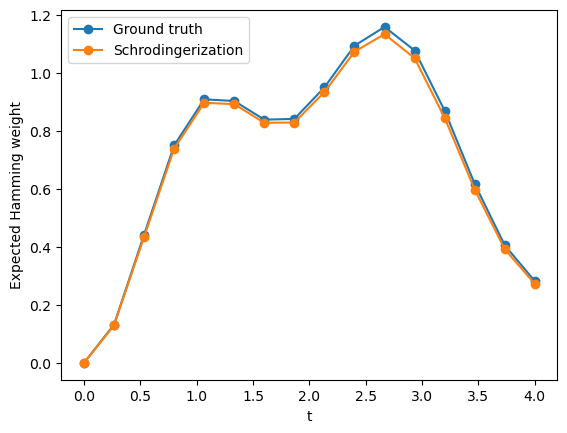

In [32]:
plt.plot(t_vals, obs_gt, '-o', label="Ground truth")
plt.plot(t_vals, obs_schrodingerization_ft, '-o', label="Schrodingerization")
plt.ylabel("Expected Hamming weight")
plt.xlabel("t")
plt.legend()
plt.show()

In [33]:
# t = T
# circuit = get_full_circuit(n_x, n_p, t, H_1, H_2, r, R, trotter_method="second_order", qft_approx_degree=qft_approx_degree)
# # compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=1)
# # print("Depth:", compiled_circuit.depth())
# # print(compiled_circuit.count_ops())

# # Run the quantum circuit on a statevector simulator backend
# # backend = Aer.get_backend('statevector_simulator')
# # job = backend.run(compiled_circuit)
# # result = job.result()
# # output_state = np.array(result.get_statevector(compiled_circuit))
# # dist_ideal = np.abs(output_state)**2

Test on simulators

In [34]:
shots_vals = [num_shots]

# amplitude_vector = np.fft.fft(np.exp(-np.abs(p)), norm="ortho")
# normalization_factor = np.linalg.norm(amplitude_vector)
# Analytical approximation of normalization factor
normalization_factor_state_prep = np.sqrt((1 - np.exp(-2 * R)) / h_p)
n = n_x + n_p
a = 0
obs_schrodingerization_circ_sim = np.zeros(N_t)

for shots in shots_vals:
    u_recover_circ_sim = np.zeros((N_t, 2 ** n_x))
    for i, t in enumerate(t_vals):
        print(f"Running t ={t : 0.2f}")

        # Simulate with sampling
        circuit = get_full_circuit(n_x, n_p, t, H_1, H_2, r, R, trotter_method=trotter_method, qft_approx_degree=qft_approx_degree)
        circuit.measure_all()
        compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=1)
        # print("Depth:", compiled_circuit.depth())
        # print(compiled_circuit.count_ops())

        # Run the quantum circuit on a statevector simulator backend
        backend = Aer.get_backend('statevector_simulator')
        job = backend.run(compiled_circuit, shots=shots)
        # job = backend.run(compiled_circuit)
        result = job.result()
        
        counts = result.get_counts(compiled_circuit)
        # print(result)
        dist_sim = np.zeros(2 ** n)
        for key in counts.keys():
            bitstring = np.zeros(n, dtype=int)
            for j in range(n):
                bitstring[j] = int(key[n-1-j])
            dist_sim[bitstring_to_int(bitstring)] = counts[key] / shots
        # plt.plot(dist_sim, label="sim")


        # # Simulate without sampling
        # circuit = get_full_circuit_naive_trotter(n_x, n_p, t, H_1, H_2, r)
        # compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=1)
        # # print("Depth:", compiled_circuit.depth())
        # # print(compiled_circuit.count_ops())

        # # Run the quantum circuit on a statevector simulator backend
        # backend = Aer.get_backend('statevector_simulator')
        # job = backend.run(compiled_circuit)
        # result = job.result()
        # output_state = np.array(result.get_statevector(compiled_circuit))
        # dist_ideal = np.abs(output_state)**2
        # plt.plot(dist_ideal, label="output")

        assert 0 <= a < R, "a is not within [0,R], increase R"
        a_idx = N_p // 2 + int(a / h_p)
        dist_sim_reshaped = np.reshape(dist_sim, newshape=(2 ** n_x, N_p))
        # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
        obs_schrodingerization_circ_sim[i] = 2 * np.sum(np.sum(dist_sim_reshaped[:,a_idx:], axis=1) * hamming_weight_operator)
        u_recover_circ_sim[i] = (normalization_factor_state_prep * np.exp(a) * np.sum(np.reshape(np.sqrt(dist_sim), newshape=(2 ** n_x, N_p))[:,a_idx:], axis=1) * h_p)[:].real
        # plt.legend()
        # plt.show()


Running t = 0.00
Running t = 0.27
Running t = 0.53
Running t = 0.80
Running t = 1.07
Running t = 1.33
Running t = 1.60
Running t = 1.87
Running t = 2.13
Running t = 2.40
Running t = 2.67
Running t = 2.93
Running t = 3.20
Running t = 3.47
Running t = 3.73
Running t = 4.00


In [35]:
obs_schrodingerization_circ_sim2 = np.zeros(N_t)
# obs_schrodingerization_circ = np.zeros(N_t)
for i in range(N_t):
    obs_schrodingerization_circ_sim2[i] = np.real(np.conj(u_recover_circ_sim[i]) @ (hamming_weight_operator * u_recover_circ_sim[i]))
    # obs_schrodingerization_circ[i] = np.real(np.conj(u_recover_circ[i]) @ (hamming_weight_operator * u_recover_circ[i]))

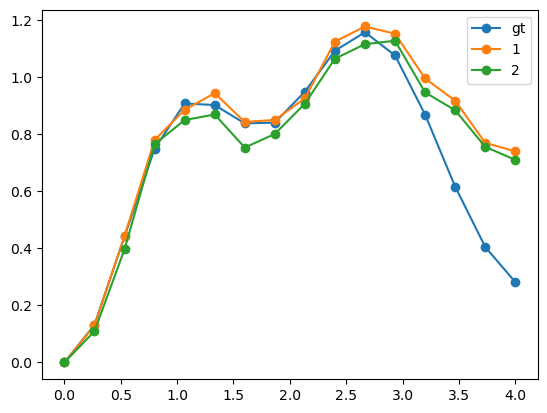

In [37]:
plt.plot(t_vals, obs_gt, '-o', label="gt")
plt.plot(t_vals, obs_schrodingerization_circ_sim, "-o", label="1")
plt.plot(t_vals, obs_schrodingerization_circ_sim2, "-o", label="2")
plt.legend()
plt.show()

In [176]:
u_recover_circ = np.zeros((N_t, 2 ** n_x))
obs_schrodingerization_circ = np.zeros(N_t)
for i, t in enumerate(t_vals):
    print(f"Running t ={t : 0.2f}")

    # Simulate without sampling
    circuit = get_full_circuit(n_x, n_p, t, H_1, H_2, r, R, trotter_method="second_order", qft_approx_degree=qft_approx_degree)
    compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=1)
    # print("Depth:", compiled_circuit.depth())
    # print(compiled_circuit.count_ops())

    # Run the quantum circuit on a statevector simulator backend
    backend = Aer.get_backend('statevector_simulator')
    job = backend.run(compiled_circuit)
    result = job.result()
    output_state = np.array(result.get_statevector(compiled_circuit))
    dist_ideal = np.abs(output_state)**2

    assert 0 <= a < R, "a is not within [0,R], increase R"
    
    a_idx = N_p // 2 + int(a / h_p)
    # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
    dist_ideal_reshaped = np.reshape(dist_ideal, newshape=(2 ** n_x, N_p))
    obs_schrodingerization_circ[i] = 2 * np.sum(np.sum(dist_ideal_reshaped[:,a_idx:], axis=1) * hamming_weight_operator)
    # u_recover_circ[i] = (normalization_factor_state_prep * np.exp(a) * np.sum(np.reshape(np.sqrt(dist_ideal), newshape=(2 ** n_x, N_p))[:,a_idx:], axis=1) * h_p)[:].real
    # plt.legend()
    # plt.show()

Running t = 0.00
Running t = 0.27
Running t = 0.53
Running t = 0.80
Running t = 1.07
Running t = 1.33
Running t = 1.60
Running t = 1.87
Running t = 2.13
Running t = 2.40
Running t = 2.67
Running t = 2.93
Running t = 3.20
Running t = 3.47
Running t = 3.73
Running t = 4.00


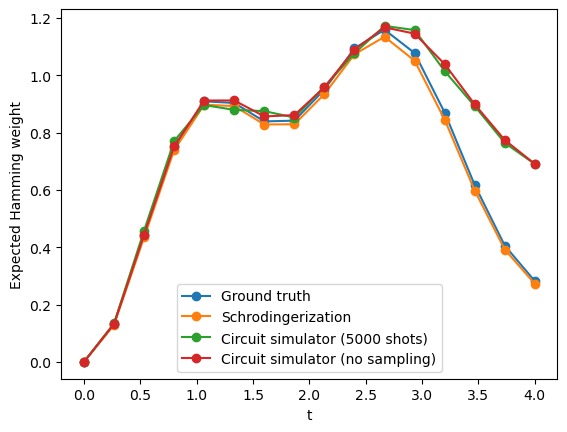

In [177]:
plt.plot(t_vals, obs_gt, '-o', label="Ground truth")
plt.plot(t_vals, obs_schrodingerization_ft, '-o', label="Schrodingerization")
plt.plot(t_vals, obs_schrodingerization_circ_sim, '-o', label=f"Circuit simulator ({num_shots} shots)")
plt.plot(t_vals, obs_schrodingerization_circ, '-o', label="Circuit simulator (no sampling)")
plt.ylabel("Expected Hamming weight")
plt.xlabel("t")
plt.legend()
plt.show()

In [178]:
circuit = get_full_circuit(n_x, n_p, T, H_1, H_2, r, R, trotter_method=trotter_method, qft_approx_degree=qft_approx_degree)
# circuit.measure_all()
compiled_circuit, current_permutation = process_swaps(transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=2))
print(compiled_circuit.count_ops())
# Check that SWAP gates are not removed by Qiskit transpiler
# U1 = Operator(circuit).to_matrix()
# U2 = Operator(compiled_circuit).to_matrix()
# assert 1 - np.abs(np.trace(U1 @ np.conj(U2.T))) / 2 ** (n_p+n_x) < 1e-6, "Check compiled circuit matches the original circuit!"

OrderedDict([('rxx', 134), ('rz', 36), ('rx', 28), ('ry', 25)])


In [179]:
instructions = get_circuit_from_qiskit(compiled_circuit)
native_instructions, qubit_phase = get_native_circuit(n, instructions)
print(get_native_gate_counts(native_instructions))

(78, 134)


In [180]:
def run_schrodingerization(experiment_info, device, save_dir, job_ids_filename, noisy_simulator=False):
    print("Running Schrodingerization")

    H_1 = - experiment_info["gamma"] * sum_delta_n(experiment_info["n_x"], delta=2 * np.ones(experiment_info["n_x"]))
    H_2 = - (experiment_info["h"] * sum_x(experiment_info["n_x"]) + experiment_info["J"] * sum_J_zz(experiment_info["n_x"], diags([np.ones(experiment_info["n_x"]-1)], [1]).toarray()))
    # A = H_1 + 1j * H_2

    t_vals = np.linspace(0, experiment_info["T"], experiment_info["N_t"])
    job_ids = []
    for i, t in enumerate(t_vals):
        print(f"Running t = {t:0.2f}")

        # Get the circuit and transpile it, removing SWAP gates
        circuit = get_full_circuit(experiment_info["n_x"], 
                                   experiment_info["n_p"], 
                                   t, 
                                   H_1, 
                                   H_2, 
                                   experiment_info["r"], 
                                   experiment_info["R"],
                                   trotter_method=experiment_info["trotter_method"], 
                                   qft_approx_degree=experiment_info["qft_approx_degree"])

        compiled_circuit, current_permutation = process_swaps(transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=2))
        assert current_permutation == list(range(experiment_info["n_x"]+experiment_info["n_p"]))

        # Check that SWAP gates do not affect the result when transpiled
        # U1 = Operator(circuit).to_matrix()
        # U2 = Operator(compiled_circuit).to_matrix()
        # assert 1 - np.abs(np.trace(U1 @ np.conj(U2.T))) / 2 ** (experiment_info["n_x"]+experiment_info["n_p"]) < 1e-6, "Check compiled circuit matches the original circuit!"

        instructions = get_circuit_from_qiskit(compiled_circuit)
        native_instructions, qubit_phase = get_native_circuit(experiment_info["n_x"]+experiment_info["n_p"], instructions)
        single_qubit_gates, two_qubit_gates = get_native_gate_counts(native_instructions)
        print(f"1q: {single_qubit_gates}, 2q: {two_qubit_gates}")
        
        # Create the job json and save it
        job = get_ionq_job_json("schrodingerization", experiment_info["n_x"]+experiment_info["n_p"], experiment_info["num_shots"], device, instructions, noisy_simulator=noisy_simulator)
        
        print(f"Saving in {save_dir}")
        with open(join(save_dir, f"job_{i}.json"), "w") as f:
            json.dump(job, f, default=int)

        # Send the job and get the job id
        job_id = send_job(job)
        print("Job id:", job_id)
        job_ids.append(job_id)
        sleep(0.3)

    print(f"Saving IonQ job ids as {job_ids_filename}")
    with open(join(save_dir, job_ids_filename), "w") as f:
        json.dump(job_ids, f)
        f.close()


# Run on IonQ simulator or real machine

In [181]:
run_schrodingerization(experiment_info, device, SAVE_DIR, job_ids_filename, noisy_simulator=False)

Running Schrodingerization
Running t = 0.00
1q: 50, 2q: 24
Saving in experiment_data/schrodingerization/ea7d38d481c92084f6255576c92b21b5
Job id: 7fabde38-e9d6-40e7-9229-4554ca591b11
Running t = 0.27
1q: 78, 2q: 134
Saving in experiment_data/schrodingerization/ea7d38d481c92084f6255576c92b21b5
Job id: 1ff642a3-f6e5-4f09-815f-7b9332fca3ec
Running t = 0.53
1q: 78, 2q: 134
Saving in experiment_data/schrodingerization/ea7d38d481c92084f6255576c92b21b5
Job id: c56c48bd-123b-4e58-8bf4-8a4770a3cfdc
Running t = 0.80
1q: 78, 2q: 134
Saving in experiment_data/schrodingerization/ea7d38d481c92084f6255576c92b21b5
Job id: a5fbf0e6-3bbf-46ad-9356-c9214040dfcc
Running t = 1.07
1q: 78, 2q: 134
Saving in experiment_data/schrodingerization/ea7d38d481c92084f6255576c92b21b5
Job id: fa00dcba-78e2-4b85-9c21-25f57d4fcf11
Running t = 1.33
1q: 78, 2q: 134
Saving in experiment_data/schrodingerization/ea7d38d481c92084f6255576c92b21b5
Job id: cf5e6d7c-edf7-4458-91f5-548d65666998
Running t = 1.60
1q: 78, 2q: 134
Savin

In [182]:
run_schrodingerization(experiment_info, device, SAVE_DIR, "job_ids_noisy_sim.json", noisy_simulator=True)

Running Schrodingerization
Running t = 0.00
1q: 50, 2q: 24
Saving in experiment_data/schrodingerization/ea7d38d481c92084f6255576c92b21b5
Job id: 49fc10a6-4234-441d-bafd-cbb5db73f33c
Running t = 0.27
1q: 78, 2q: 134
Saving in experiment_data/schrodingerization/ea7d38d481c92084f6255576c92b21b5
Job id: 5817a0cf-77ca-4d7f-82ec-9166e138e2e4
Running t = 0.53
1q: 78, 2q: 134
Saving in experiment_data/schrodingerization/ea7d38d481c92084f6255576c92b21b5
Job id: cc13c38c-8923-49fc-a0de-36db998fdc07
Running t = 0.80
1q: 78, 2q: 134
Saving in experiment_data/schrodingerization/ea7d38d481c92084f6255576c92b21b5
Job id: 5be8fcdf-19f4-46f2-b9c2-a608ec63c562
Running t = 1.07
1q: 78, 2q: 134
Saving in experiment_data/schrodingerization/ea7d38d481c92084f6255576c92b21b5
Job id: 35001099-2f99-44a2-894d-d55a4ec3f72d
Running t = 1.33
1q: 78, 2q: 134
Saving in experiment_data/schrodingerization/ea7d38d481c92084f6255576c92b21b5
Job id: 399fdd55-f274-42da-a945-b5fa11463983
Running t = 1.60
1q: 78, 2q: 134
Savin

## Post processing

In [187]:
def post_processing(experiment_info, job_ids_filename, save_dir, use_correction=False):
    # t_vals = np.linspace(0, experiment_info["T"], experiment_info["N_t"])
    # h_p = (2 * experiment_info["R"]) / (2 ** experiment_info["n_p"] - 1)

    # H_1 = - experiment_info["gamma"] * sum_delta_n(experiment_info["n_x"], delta=2 * np.ones(experiment_info["n_x"]))
    # H_2 = - (experiment_info["h"] * sum_x(experiment_info["n_x"]) + experiment_info["J"] * sum_J_zz(experiment_info["n_x"], diags([np.ones(experiment_info["n_x"]-1)], [1]).toarray()))
    dimension = 2 ** experiment_info["n_x"]
    # A = H_1 + 1j * H_2

    # Get the job ids
    with open(join(save_dir, job_ids_filename), "r") as f:
        job_ids = json.load(f)
        f.close()

    obs_schrodingerization = np.zeros((experiment_info["N_t"]))
    # normalization_factor_state_prep = np.sqrt((1 - np.exp(-2 * experiment_info["R"])) / h_p)
    # normalization_factor_state_prep = np.linalg.norm(np.exp(-np.abs(p)))
    # Get the job results
    for i, job_id in enumerate(job_ids):
        
        results = get_ionq_single_job_result(job_id)

        freq = np.zeros(2 ** (experiment_info["n_p"] + experiment_info["n_x"]))
        for j in range(2 ** (experiment_info["n_p"] + experiment_info["n_x"])):
            if str(j) in results.keys():
                freq[j] = results[str(j)]
        freq_reshaped = np.reshape(freq, newshape=(dimension, N_p))
        # a = np.sum(p * np.sum(freq_reshaped, axis=0))

        if use_correction:
            a = p[np.argmax(np.sum(freq_reshaped, axis=0))]
            # print(f"a={a}")
            a = max(a, 0)
        else:
            a = 0

        laplace_dist = np.exp(-np.abs(p-a))
        laplace_dist *= np.sqrt(np.max(np.sum(freq_reshaped, axis=0)))
        # plt.plot(p, np.abs(laplace_dist) ** 2, label="Ideal", color="blue", alpha=0.5)
        # plt.plot(p, np.sum(freq_reshaped, axis=0), label="Noisy", color="red", alpha=0.5)
        # plt.show()

        # lambda_min = -norm(b)/2
        # a = -lambda_min * t
        assert 0 <= a < R, "a is not within [0,R], increase R"
        a_idx = N_p // 2 + int(a / h)

        # for j in range(dimension):
        #     plt.plot(p, np.sqrt(freq_reshaped[j,:]), label=f"x_{j}")
        # plt.title(f"Uncorrected distribution t={t_vals[i]:0.2f}")
        # plt.xlabel("p")
        # plt.ylabel("Frequency")
        # plt.legend()
        # plt.show()

        obs_schrodingerization[i] = 2 * np.sum(np.sum(freq_reshaped[:,a_idx:], axis=1) * hamming_weight_operator)
        # u_recover[i] = (normalization_factor_state_prep * np.exp(a) * np.sum(np.reshape(np.sqrt(freq_reshaped), newshape=(dimension, N_p))[:,a_idx:], axis=1) * h_p)[:]
        # lambda_min = -norm(b)/2
        # a = -lambda_min * t
        # assert 0 <= a < experiment_info["R"], "a is not within [0,R], increase R"
        # a_idx = (2 ** experiment_info["n_p"]) // 2 + int(a / h)
        # # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
        
        # for j in results.keys():
        #     bitstring = np.binary_repr(int(j), experiment_info["n_x"] + experiment_info["n_p"])
        #     x_idx = int(bitstring[:experiment_info["n_x"]], 2)
        #     p_idx = int(bitstring[experiment_info["n_x"]:], 2)
        #     # Integrate from a to R
        #     if x_idx < dimension and p_idx >= a_idx:
        #         if use_correction:
        #             u_recover[i][x_idx] += np.sqrt(results[str(j)] * correction[p_idx])
        #         else:
        #             u_recover[i][x_idx] += np.sqrt(results[str(j)])

        # u_recover[i] *= normalization_factor_state_prep * np.exp(a) * h

    return obs_schrodingerization

Get the results

In [188]:
obs_schrodingerization_ideal_sim = post_processing(experiment_info, job_ids_filename, SAVE_DIR, use_correction=False)

Getting job: 7fabde38-e9d6-40e7-9229-4554ca591b11
Job status: completed
Getting job: 1ff642a3-f6e5-4f09-815f-7b9332fca3ec
Job status: completed
Getting job: c56c48bd-123b-4e58-8bf4-8a4770a3cfdc
Job status: completed
Getting job: a5fbf0e6-3bbf-46ad-9356-c9214040dfcc
Job status: completed
Getting job: fa00dcba-78e2-4b85-9c21-25f57d4fcf11
Job status: completed
Getting job: cf5e6d7c-edf7-4458-91f5-548d65666998
Job status: completed
Getting job: a53ac911-663a-4e4d-a57f-9b29caea8ee2
Job status: completed
Getting job: 4172788a-dbe6-4552-8ff0-797fb2f60a65
Job status: completed
Getting job: 55a22482-cee1-4a89-896a-8132d52b9167
Job status: completed
Getting job: 9e30c4bb-aa1d-4c6c-a040-00b2c2539a61
Job status: completed
Getting job: 700403e7-8993-4a5e-b472-c564fc35f65d
Job status: completed
Getting job: 43e1c7a1-1ec3-47eb-a230-43229086a2d4
Job status: completed
Getting job: 72427b70-194d-4245-be94-4ee223b37e43
Job status: completed
Getting job: 888c2ec2-5efa-4a43-928e-b09586a4bb71
Job status: co

In [194]:
obs_schrodingerization_noisy_sim = post_processing(experiment_info, "job_ids_noisy_sim.json", SAVE_DIR, use_correction=False)
# u_recover_noisy_sim_corrected = post_processing(experiment_info, "job_ids_noisy_sim.json", SAVE_DIR, use_correction=True)

Getting job: 49fc10a6-4234-441d-bafd-cbb5db73f33c
Job status: completed
Getting job: 5817a0cf-77ca-4d7f-82ec-9166e138e2e4
Job status: completed
Getting job: cc13c38c-8923-49fc-a0de-36db998fdc07
Job status: completed
Getting job: 5be8fcdf-19f4-46f2-b9c2-a608ec63c562
Job status: completed
Getting job: 35001099-2f99-44a2-894d-d55a4ec3f72d
Job status: completed
Getting job: 399fdd55-f274-42da-a945-b5fa11463983
Job status: completed
Getting job: 0786fa23-ed8c-4cc3-912d-e70fffb2d3e5
Job status: completed
Getting job: 90d6eb6a-8b8d-4ca2-9d1d-76daa8fb65f5
Job status: completed
Getting job: bc1beaa0-8610-4967-869b-60a60edf8ec9
Job status: completed
Getting job: ffb96cdd-ed09-4b16-aaa3-d721cd0bd949
Job status: completed
Getting job: c894a8c3-9def-4791-a857-00cad73e81d0
Job status: completed
Getting job: 9dc977b3-a334-4b03-8cfe-874abc9a2900
Job status: completed
Getting job: e8f43f25-c8aa-4cf7-a5fb-19be9adaddd7
Job status: completed
Getting job: cff87ad4-50e9-4bdc-b81c-33b01ca86d68
Job status: co

# Plot the results

In [195]:
# obs_schrodingerization_ideal_sim = np.zeros(N_t)
# obs_schrodingerization_noisy_sim_uncorrected = np.zeros(N_t)
# obs_schrodingerization_noisy_sim_corrected = np.zeros(N_t)
# for i in range(N_t):
#     obs_schrodingerization_ideal_sim[i] = np.real(np.conj(u_recover_sim[i]) @ (hamming_weight_operator * u_recover_sim[i]))
#     obs_schrodingerization_noisy_sim_uncorrected[i] = np.real(np.conj(u_recover_noisy_sim_uncorrected[i]) @ (hamming_weight_operator * u_recover_noisy_sim_uncorrected[i]))
#     obs_schrodingerization_noisy_sim_corrected[i] = np.real(np.conj(u_recover_noisy_sim_corrected[i]) @ (hamming_weight_operator * u_recover_noisy_sim_corrected[i]))

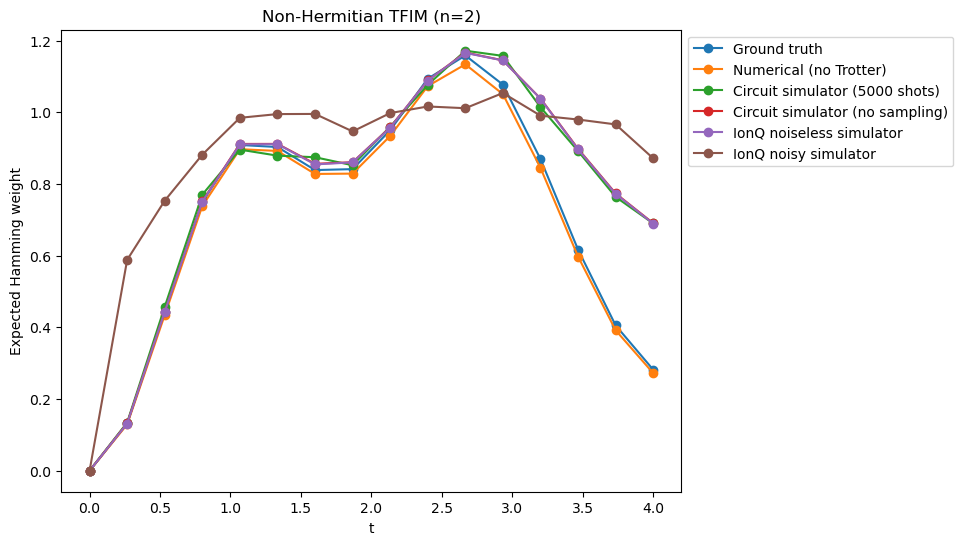

In [196]:
plt.figure(figsize=(8, 6))
plt.plot(t_vals, obs_gt, '-o', label="Ground truth")
plt.plot(t_vals, obs_schrodingerization_ft, '-o', label="Numerical (no Trotter)")
plt.plot(t_vals, obs_schrodingerization_circ_sim, '-o', label=f"Circuit simulator ({num_shots} shots)")
plt.plot(t_vals, obs_schrodingerization_circ, '-o', label="Circuit simulator (no sampling)")

plt.plot(t_vals, obs_schrodingerization_ideal_sim, '-o', label=f"IonQ noiseless simulator")
plt.plot(t_vals, obs_schrodingerization_noisy_sim, '-o', label="IonQ noisy simulator")
# plt.plot(t_vals, obs_schrodingerization_noisy_sim_corrected, '-o', label="IonQ noisy simulator, post-processed")

plt.title(f"Non-Hermitian TFIM (n={n_x})")
plt.ylabel("Expected Hamming weight")
plt.xlabel("t")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()